**Author**:
- Tianci Wang - [tiancwang@ethz.ch](tianci:tiancwang@ethz.ch)

**Date**: 2025-05-21

# Policy Optimization Experiment Code v1.0
This code is used to perform policy optimization after obtaining the scores of all policies with different intensity levels using the PROMETHEE II method.
## Input data
1. Policy IDs, MCDA ranking scores, and the corresponding supported technologies;
2. Relative technology support level needs in the MIX, REMIX, and H2 scenarios compared with the baseline scenario Swiss Energy Perspectives 2050+ (EP2050+).
## Workflow
The code consists of four main steps:
1. Data preparation:

   Shift the MCDA scores to create a non-negative dataset for the technology support level calculation, and assign scores to each technology based on the technology support ratio.
2. Technology support level calculation:

   Calculate the technology support levels for the EP2050+ scenario and derive the corresponding support levels for the MIX, REMIX, and H2 scenarios.
3. Policy optimization:

   Optimize the policy selection for the MIX, REMIX, and H2 scenarios by minimizing costs while considering policy incompatibilities.
4. Result visualization:

   Generate the final plots to present the optimized policy portfolio results.
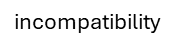

## 0 Import libraries and data

In [35]:
# Import Libraries
import pandas as pd
import numpy as np
import pulp
import matplotlib.pyplot as plt
import seaborn as sns

# Import data
from config import POLICY_TABLE, SCENARIO_TABLE
df_policies = pd.read_csv(POLICY_TABLE)
df_scenarios = pd.read_csv(SCENARIO_TABLE)


## 1 Data preparation:
Shift the MCDA scores to create a non-negative dataset for the technology support level calculation, and assign scores to each technology based on the technology support ratio.
### 1.1 Non-Negative Score Shifting
To prevent negative resource distribution during the downstream optimization phases, the raw PROMETHEE II Net Flow ($\Phi$) scores are converted into a strictly non-negative dataset.

This is achieved by locating the absolute global minimum Net Flow score across all policy alternatives and applying a uniform upward translation shift ($+\lvert \Phi_{min} \rvert + 0.01$).

This preserves the absolute ordinal distance and performance variance between policy intensities while anchoring the baseline minimum score slightly above zero.

In [36]:
# Create a clean working copy of the policy dataframe
df_policies_clean = df_policies.copy()

# Find the global minimum value in the Net Flow column
min_net_flow = df_policies_clean['Net_Flow'].min()

print(f"--- Step 1.1 Execution ---")
print(f"Minimum Net Flow discovered in dataset: {min_net_flow:.4f}")

# Execute the transformation shift if negative values exist
if min_net_flow <= 0:
    shift_constant = abs(min_net_flow) + 0.01
    df_policies_clean['Shifted_Score'] = df_policies_clean['Net_Flow'] + shift_constant
    print(f"Action: Shifted all scores by adding a constant of {shift_constant:.4f}")
else:
    df_policies_clean['Shifted_Score'] = df_policies_clean['Net_Flow']
    print("Action: No shift required. All scores are already non-negative.")

# Preview the top entries to verify the conversion
print(df_policies_clean[['Policy_ID', 'Net_Flow', 'Shifted_Score']].head())

--- Step 1.1 Execution ---
Minimum Net Flow discovered in dataset: -0.4892
Action: Shifted all scores by adding a constant of 0.4992
  Policy_ID  Net_Flow  Shifted_Score
0    I_01_4  0.137634       0.636882
1    I_01_5  0.137634       0.636882
2    I_01_3  0.067742       0.566989
3    I_01_2 -0.022581       0.476667
4    I_01_1 -0.027957       0.471290


### 1.2 Technology-Weighted Score Mapping
In order to quantify the specific operational impact of each policy instrument on individual energy sectors, the non-negative Shifted_Score is mapped directly to the targeted technologies.

This is achieved by taking the pre-defined technology contribution ratios—which are manually established in the input matrix and multiplying them directly by the policy's overall performance score. The resulting weighted matrix serves as the fundamental baseline for calculating aggregated technology support levels across the distinct Swiss energy scenarios.

In [37]:
# Replace any blank cells or NaN markers in your technology support columns with 0
tech_columns = [
    'Biomass_Boiler',	'Heat_Pump',	'Methane_Boiler',	'CCGT_Ren_Methane',
    'CHP_waste',	'CHP_Ren_Methane',	'Hydro_reservoir',	'Hydro_run_of',	'PV_Roof',
    'Pumped_Hydro',	'Wind',	'CCGT_Gas_DACCS',	'Alpine_PV',	'Heavy_EV',	'Heavy_FCEV',
    'Light_EV',	'Light_FCEV'
]

existing_tech_cols = [col for col in tech_columns if col in df_policies_clean.columns]
df_policies_clean[existing_tech_cols] = df_policies_clean[existing_tech_cols].fillna(0)

# Multiply each technology ratio directly by the non-negative Shifted Score
for col in existing_tech_cols:
    df_policies_clean[col] = df_policies_clean[col] * df_policies_clean['Shifted_Score']

print("Step 1 complete: Scores successfully distributed across expert tech ratios.")
# Preview the updated rows to see the raw performance points per technology
print(df_policies_clean[['Policy_ID', 'Shifted_Score'] + existing_tech_cols[:3]].head())

Step 1 complete: Scores successfully distributed across expert tech ratios.
  Policy_ID  Shifted_Score  Biomass_Boiler  Heat_Pump  Methane_Boiler
0    I_01_4       0.636882        0.127376   0.127376        0.127376
1    I_01_5       0.636882        0.127376   0.127376        0.127376
2    I_01_3       0.566989        0.113398   0.113398        0.113398
3    I_01_2       0.476667        0.095333   0.095333        0.095333
4    I_01_1       0.471290        0.094258   0.094258        0.094258


## 2 Technology support level calculation
Calculate the technology support levels for the EP2050+ scenario and derive the corresponding support levels for the MIX, REMIX, and H2 scenarios.
### 2.1 Establish the EP2050+ Baseline
To establish a quantitative anchor for the baseline scenario (Swiss Energy Perspectives 2050+), the technology support levels are calculated by aggregating the weighted performance scores of all currently active policies.

These policies are identified within the policy dataset where the implementation intensity level is exactly equal to 3. Summing these scores column-wise across each unique technology vector generates the absolute point baseline representing the status-quo technology support levels.

In [38]:
# Filter the dataset to isolate policies representing current instruments (Intensity == 3)
df_intensity_3 = df_policies_clean[df_policies_clean['Policy_Intensity'] == 3]

# Compute the column-wise sum for the technology pillars to build the baseline series
ep2050_baseline = df_intensity_3[existing_tech_cols].sum()

# Convert it to a clean DataFrame for clear viewing
df_ep2050 = pd.DataFrame(ep2050_baseline).T
df_ep2050.index = ['EP2050+']

print("✅ EP2050+ Baseline support points successfully aggregated per technology:")
print(df_ep2050)

✅ EP2050+ Baseline support points successfully aggregated per technology:
         Biomass_Boiler  Heat_Pump  Methane_Boiler  CCGT_Ren_Methane  \
EP2050+        1.126898   1.419371        0.465719          0.587515   

         CHP_waste  CHP_Ren_Methane  Hydro_reservoir  Hydro_run_of  PV_Roof  \
EP2050+   1.147262          1.68608         0.735459      0.735459  1.49829   

         Pumped_Hydro      Wind  CCGT_Gas_DACCS  Alpine_PV  Heavy_EV  \
EP2050+      0.735459  1.052215        0.098559    1.49829  2.034919   

         Heavy_FCEV  Light_EV  Light_FCEV  
EP2050+    1.382424  1.599113    0.825112  


### 2.2 Calculate Targets Based on the Scenario Deviations
Using the established EP2050+ baseline as a structural foundation, the absolute technology support level requirements for the alternative strategic trajectories (MIX, REMIX, and H2) are derived.

The relative percentage deviations provided in the scenario matrix are parsed and converted into multipliers. Each alternative scenario's target support profile is calculated by multiplying the baseline values by their respective scenario-specific adjustment factor $(1 + \Delta\%)$, capturing the explicit policy-driven expansion or contraction required for each energy sector.

In [39]:
# Create a working copy of your scenario table (df2)
# Set the scenario name ('EP2050+', 'MIX', etc.) as the index to match easily
df_scenarios_clean = df_scenarios.copy()
if 'Scenario' in df_scenarios_clean.columns:
    df_scenarios_clean.set_index('Scenario', inplace=True)
elif df_scenarios_clean.columns[0] != '':
    # If the first column is unnamed or acts as the text label, set it as index
    df_scenarios_clean.set_index(df_scenarios_clean.columns[0], inplace=True)

# Create an empty dictionary to store the calculated absolute targets
scenario_targets = {'EP2050+': ep2050_baseline.to_dict()}

# Loop through the target optimization scenarios
for scenario in ['MIX', 'REMIX', 'H2']:
    scenario_targets[scenario] = {}

    for tech in existing_tech_cols:
        raw_val = df_scenarios_clean.loc[scenario, tech]
        # Safe-handling for strings with '%' symbol or actual floats
        if isinstance(raw_val, str):
            pct_change = float(raw_val.replace('%', '').strip()) / 100.0
        else:
            # If it's already a float like 0.2616 or 26.16 (depending on how CSV saved it)
            # If saved as 26.16 instead of 0.2616, divide by 100
            pct_change = raw_val / 100.0 if abs(raw_val) > 1.0 else raw_val

        # Formula: Target Support = Baseline Score * (1 + Percentage Change)
        base_score = ep2050_baseline[tech]
        scenario_targets[scenario][tech] = base_score * (1.0 + pct_change)

# Combine the results into a DataFrame
df_target_matrix = pd.DataFrame(scenario_targets).T

print("Step 2 complete: Absolute Technology Support Targets for all Scenarios:")
print(df_target_matrix.round(4))

Step 2 complete: Absolute Technology Support Targets for all Scenarios:
         Biomass_Boiler  Heat_Pump  Methane_Boiler  CCGT_Ren_Methane  \
EP2050+          1.1269     1.4194          0.4657            0.5875   
MIX              0.8829     1.7907          0.4583            0.5875   
REMIX            1.0189     1.5789          0.4583            0.6041   
H2               1.1428     1.2811          0.5157            0.5875   

         CHP_waste  CHP_Ren_Methane  Hydro_reservoir  Hydro_run_of  PV_Roof  \
EP2050+     1.1473           1.6861           0.7355        0.7355   1.4983   
MIX         1.1473           1.6588           0.7419        0.7355   1.4647   
REMIX       1.1473           1.6588           0.7355        0.7355   1.4650   
H2          1.1473           1.6861           0.7462        0.7355   1.4983   

         Pumped_Hydro    Wind  CCGT_Gas_DACCS  Alpine_PV  Heavy_EV  \
EP2050+        0.7355  1.0522          0.0986     1.4983    2.0349   
MIX            0.7464  1.0750  

## 3 Policy optimization
Optimize the policy selection for the MIX, REMIX, and H2 scenarios by minimizing costs while considering policy incompatibilities.

To determine the optimal policy instrument portfolios for the MIX, REMIX, and H2 pathways, a Mixed-Integer Linear Programming (MILP) optimization framework is constructed, mimicking a decentralized multi-choice knapsack structure.

Let $x_{p,i} \in \{0, 1\}$ represent the binary decision to select policy instrument $p$ at implementation intensity level $i$.

The primary objective is to meet scenario-specific technological support thresholds. Crucially, strict upper bounds are enforced on technology points to prevent over-allocation and ensure structural efficiency.

Alternative structural portfolios are generated iteratively by injecting integer exclusion cuts into the constraint matrix, yielding the first three distinct policy combinations.

### 3.1 Initialize the Multi-Choice Variables and Exclusivity Constraints
The optimization framework is initialized by establishing binary decision variables $x_{p,i} \in \{0, 1\}$, where a value of 1 denotes the absolute selection of policy instrument $p$ at a specific intensity level $i$.

To ensure realistic policy deployment, a structural constraint enforces mutual exclusivity within each policy instrument family. This mathematical rule dictates that while a policy can be selected at intensity level 1, 2, or 3, it is restricted from being simultaneously active at multiple intensities, represented as $\sum_{i} x_{p,i} \le 1$ for all base instruments.